In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data

In [2]:
df = pd.read_csv('cleaned_data.csv')
df['genres'] = df['genres'].apply(lambda x: x.split(';') if pd.notnull(x) else [])
df.head()

,url,title,genres,description
0,https://www.filmweb.pl/film/Zielona+mila-1999-862,Zielona mila,[Dramat],Rok 1935. Paul Edgecombe (Tom Hanks) jest jedn...
1,https://www.filmweb.pl/film/Skazani+na+Shawsha...,Skazani na Shawshank,[Dramat],Film nakręcony na podstawie książki mistrza ho...
2,https://www.filmweb.pl/film/Forrest+Gump-1994-998,Forrest Gump,"[Dramat, Komedia]","""Forrest Gump"" to romantyczna historia, w któr..."
3,https://www.filmweb.pl/film/Leon+zawodowiec-19...,Leon zawodowiec,"[Dramat, Kryminał]",Leon (Jean Reno) jest płatnym zabójcą. W niczy...
4,https://www.filmweb.pl/film/Requiem+dla+snu-20...,Requiem dla snu,[Dramat],Wstrząsająca opowieść o czwórce bohaterów z Br...


## Genres

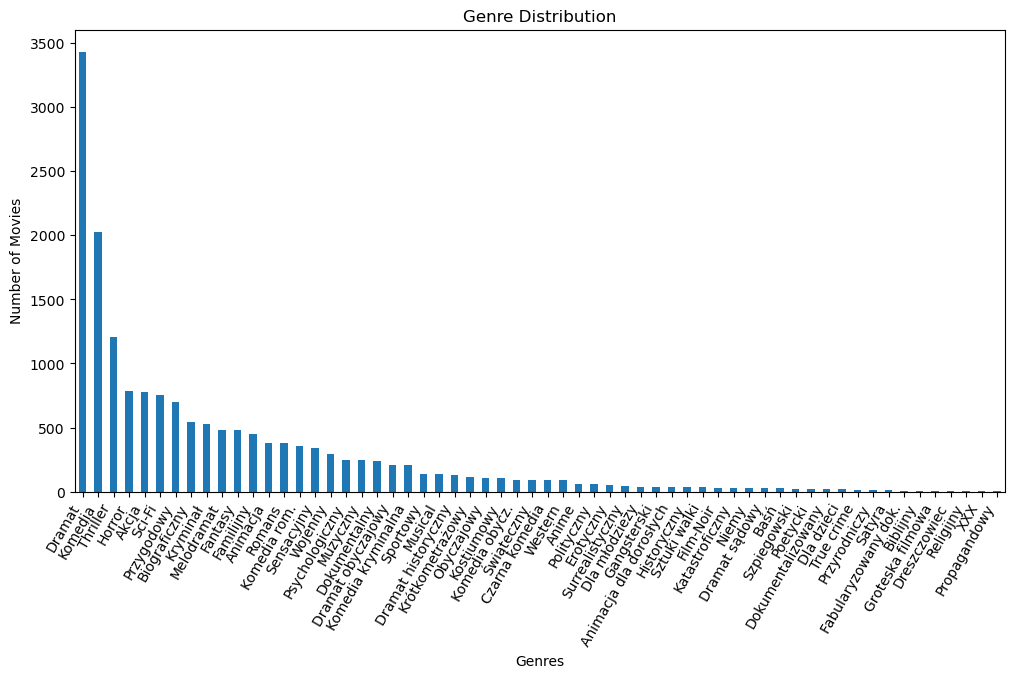

In [3]:
genre_count = df['genres'].explode().value_counts()

genre_count.plot(kind='bar', title='Genre Distribution', ylabel='Number of Movies', xlabel='Genres', figsize=(12, 6))
plt.xticks(rotation=60, ha='right')
# plt.savefig('genre_distribution.png')
plt.show()

In [4]:
print(genre_count)

genres
Dramat                    3432
Komedia                   2025
Thriller                  1205
Horror                     788
Akcja                      781
Sci-Fi                     757
Przygodowy                 699
Biograficzny               540
Kryminał                   529
Melodramat                 482
Fantasy                    480
Familijny                  446
Animacja                   382
Romans                     376
Komedia rom.               355
Sensacyjny                 341
Wojenny                    292
Psychologiczny             247
Muzyczny                   244
Dokumentalny               241
Dramat obyczajowy          210
Komedia kryminalna         207
Sportowy                   140
Musical                    138
Dramat historyczny         127
Krótkometrażowy            117
Obyczajowy                 109
Kostiumowy                 104
Komedia obycz.              94
Świąteczny                  94
Czarna komedia              91
Western                     87
A

In [5]:
num_unique_genres = genre_count.shape[0]
print(f'Number of unique genres: {num_unique_genres}')

Number of unique genres: 60


In [6]:
average_genres_per_movie = genre_count.sum() / df.shape[0]
print(f'Average number of genres per movie: {average_genres_per_movie:.2f}')

Average number of genres per movie: 1.77


In [7]:
genres = df['genres'].explode().unique()
list(genres)

['Dramat',
 'Komedia',
 'Kryminał',
 'Sci-Fi',
 'Akcja',
 'Thriller',
 'Dramat historyczny',
 'Gangsterski',
 'Przygodowy',
 'Fantasy',
 'Familijny',
 'Dramat obyczajowy',
 'Biograficzny',
 'Kostiumowy',
 'Horror',
 'Melodramat',
 'Psychologiczny',
 'Dreszczowiec',
 'Animacja',
 'Polityczny',
 'Erotyczny',
 'Komedia kryminalna',
 'Sportowy',
 'Wojenny',
 'Czarna komedia',
 'Musical',
 'Romans',
 'Dokumentalny',
 'Sensacyjny',
 'Western',
 'Komedia obycz.',
 'Historyczny',
 'Komedia rom.',
 'Krótkometrażowy',
 'Groteska filmowa',
 'Satyra',
 'Szpiegowski',
 'Świąteczny',
 'Muzyczny',
 'Surrealistyczny',
 'Anime',
 'Obyczajowy',
 'Poetycki',
 'Dla dzieci',
 'Sztuki walki',
 'Dla młodzieży',
 'Biblijny',
 'Niemy',
 'Katastroficzny',
 'Dramat sądowy',
 'Animacja dla dorosłych',
 'Baśń',
 'Film-Noir',
 'Dokumentalizowany',
 'Religijny',
 'Fabularyzowany dok.',
 'XXX',
 'True crime',
 'Przyrodniczy',
 'Propagandowy']

## Descriptions

In [8]:
df['description_word_count'] = df['description'].apply(lambda x: len(str(x).split()))
average_word_count = df['description_word_count'].mean()
print(f'Average word count in descriptions: {average_word_count:.2f}')
print(f'Maximum word count in descriptions: {df["description_word_count"].max()}')
print(f'Minimum word count in descriptions: {df["description_word_count"].min()}')

Average word count in descriptions: 81.74
Maximum word count in descriptions: 555
Minimum word count in descriptions: 14


# Model

In [9]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [10]:
class MoviesDataset(torch.utils.data.Dataset):
	def __init__(self, encodings, labels):
		self.encodings = encodings
		self.labels = labels

	def __getitem__(self, idx):
		return {
			'input_ids': torch.tensor(self.encodings['input_ids'][idx], dtype=torch.long),
			'attention_mask': torch.tensor(self.encodings['attention_mask'][idx], dtype=torch.long),
			'labels': torch.tensor(self.labels[idx], dtype=torch.float)
		}
	
	def __len__(self):
		return len(self.labels)

In [11]:
def build_label_mappings(df: pd.DataFrame) -> tuple[dict, dict]:
	all_genres = df['genres'].explode().unique()
	genre_to_idx = {genre: idx for idx, genre in enumerate(all_genres)}
	index_to_genre = {idx: genre for genre, idx in genre_to_idx.items()}
	return genre_to_idx, index_to_genre

def build_dataset(df: pd.DataFrame, genre_to_idx: dict, tokenizer_name: str="allegro/herbert-base-cased", max_length: int=512) -> MoviesDataset:
	num_labels = len(genre_to_idx)

	# Multi-hot encoding of genres
	def encode_genres(genres_list):
		vec = np.zeros(num_labels, dtype=int)
		for genre in genres_list:
			if genre in genre_to_idx:
				vec[genre_to_idx[genre]] = 1
		return vec
	labels = df['genres'].apply(encode_genres).tolist()

	# Tokenization
	tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
	encodings = tokenizer(
		df['description'].tolist(),
		padding=True,
		truncation=True,
		max_length=max_length
	)

	dataset = MoviesDataset(encodings, labels)

	return dataset

In [12]:
class HerBERTMultiLabelClassifier(torch.nn.Module):
	def __init__(self, num_labels: int, model_name: str="allegro/herbert-base-cased", dropout: float=0.25):
		super().__init__()
		self.encoder = AutoModel.from_pretrained(model_name)
		hidden_size = self.encoder.config.hidden_size

		self.classifier = torch.nn.Sequential(
			torch.nn.Dropout(dropout),
			torch.nn.Linear(hidden_size, hidden_size // 2),
			torch.nn.ReLU(),
			torch.nn.Dropout(dropout),
			torch.nn.Linear(hidden_size // 2, num_labels)
		)

	def forward(self, input_ids, attention_mask):
		outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
		cls_output = outputs.last_hidden_state[:, 0, :]  # CLS token output
		logits = self.classifier(cls_output)
		return logits

In [ ]:
def train_model(
	model: torch.nn.Module,
	train_loader: torch.utils.data.DataLoader,
	val_loader: torch.utils.data.DataLoader,
	num_epochs: int,
	learning_rate: float = 1e-4,
	device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
	threshold: float = 0.25
) -> torch.nn.Module:
	
	model.to(device)
	optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
	criterion = torch.nn.BCEWithLogitsLoss()

	for epoch in range(num_epochs):
		# Training
		model.train()
		total_loss = 0
		for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training'):
			optimizer.zero_grad()
			input_ids = batch['input_ids'].to(device)
			attention_mask = batch['attention_mask'].to(device)
			labels = batch['labels'].to(device).float()

			logits = model(input_ids=input_ids, attention_mask=attention_mask)
			loss = criterion(logits, labels)
			loss.backward()
			optimizer.step()

			total_loss += loss.item()

		avg_loss = total_loss / len(train_loader)

		# Validation
		model.eval()
		val_loss = 0
		all_labels = []
		all_preds = []
		with torch.no_grad():
			for batch in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Validation'):
				input_ids = batch['input_ids'].to(device)
				attention_mask = batch['attention_mask'].to(device)
				labels = batch['labels'].to(device) # .float() ?

				logits = model(input_ids=input_ids, attention_mask=attention_mask)
				loss = criterion(logits, labels) # .float() ?
				val_loss += loss.item()

				probabilities = torch.sigmoid(logits)
				predictions = (probabilities > threshold).int()

				all_labels.append(labels.cpu().int())
				all_preds.append(predictions.cpu())

		avg_val_loss = val_loss / len(val_loader)

		all_labels = torch.cat(all_labels)
		all_preds = torch.cat(all_preds)

		label_wise_accuracy = (all_labels == all_preds).float().mean().item() # label-wise accuracy
		sample_wise_accuracy = ((all_labels == all_preds).all(dim=1)).float().mean().item() # sample-wise accuracy
		f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) # F1 score
		f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0) # Micro F1 score

		print(f'Epoch {epoch + 1}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
		print(f'Validation metrics: Label-wise Accuracy: {label_wise_accuracy:.4f}, Sample-wise Accuracy: {sample_wise_accuracy:.4f}, F1 Score: {f1:.4f}, Micro F1 Score: {f1_micro:.4f}')

	return model

In [14]:
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

genre_to_idx, idx_to_genre = build_label_mappings(df)
train_dataset = build_dataset(df_train, genre_to_idx)
validation_dataset = build_dataset(df_val, genre_to_idx)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)

In [ ]:
num_labels = len(genre_to_idx)
model = HerBERTMultiLabelClassifier(num_labels=num_labels)

trained_model = train_model(
    model=model,
    train_loader=train_loader,
	val_loader=validation_loader,
	num_epochs=5
)

Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/5 Validation: 100%|██████████| 119/119 [00:47<00:00,  2.52it/s]


Epoch 1, Train Loss: 0.1267, Val Loss: 0.0938, Val Accuracy: 0.9706


Epoch 2/5 Validation: 100%|██████████| 119/119 [00:49<00:00,  2.41it/s]


Epoch 2, Train Loss: 0.0999, Val Loss: 0.1044, Val Accuracy: 0.9703


Epoch 3/5 Training:  72%|███████▏  | 343/476 [39:58<21:43,  9.80s/it]

In [ ]:
# save the model
torch.save(trained_model.state_dict(), 'herbert_multilabel_classifier.pth')

In [ ]:
# TODO: Class weights balancing for imbalanced dataset
# TODO: Early stopping mechanism? 
# TODO: Try freezing HerBERT layers
# TODO: learn more about gradient clipping

### Weighted loss

In [16]:
weights = genre_count.min() / genre_count
print(weights)

genres
Dramat                    0.000583
Komedia                   0.000988
Thriller                  0.001660
Horror                    0.002538
Akcja                     0.002561
Sci-Fi                    0.002642
Przygodowy                0.002861
Biograficzny              0.003704
Kryminał                  0.003781
Melodramat                0.004149
Fantasy                   0.004167
Familijny                 0.004484
Animacja                  0.005236
Romans                    0.005319
Komedia rom.              0.005634
Sensacyjny                0.005865
Wojenny                   0.006849
Psychologiczny            0.008097
Muzyczny                  0.008197
Dokumentalny              0.008299
Dramat obyczajowy         0.009524
Komedia kryminalna        0.009662
Sportowy                  0.014286
Musical                   0.014493
Dramat historyczny        0.015748
Krótkometrażowy           0.017094
Obyczajowy                0.018349
Kostiumowy                0.019231
Komedia obycz

In [17]:
def train_model_with_weighted_loss(
	model: torch.nn.Module,
	train_loader: torch.utils.data.DataLoader,
	val_loader: torch.utils.data.DataLoader,
	num_epochs: int,
	learning_rate: float = 1e-4,
	device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
):
	model.to(device)
	optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
	pos_weight = torch.tensor(weights.values, dtype=torch.float32).to(device)
	criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

	for epoch in range(num_epochs):
		# Training
		model.train()
		total_loss = 0
		for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training'):
			optimizer.zero_grad()
			input_ids = batch['input_ids'].to(device)
			attention_mask = batch['attention_mask'].to(device)
			labels = batch['labels'].to(device).float()

			logits = model(input_ids=input_ids, attention_mask=attention_mask)
			loss = criterion(logits, labels)
			loss.backward()
			optimizer.step()

			total_loss += loss.item()

		avg_loss = total_loss / len(train_loader)

		# Validation
		model.eval()
		val_loss = 0
		all_labels = []
		all_preds = []
		with torch.no_grad():
			for batch in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Validation'):
				input_ids = batch['input_ids'].to(device)
				attention_mask = batch['attention_mask'].to(device)
				labels = batch['labels'].to(device) # .float() ?

				logits = model(input_ids=input_ids, attention_mask=attention_mask)
				loss = criterion(logits, labels) # .float() ?
				val_loss += loss.item()

				probabilities = torch.sigmoid(logits)
				predictions = (probabilities > 0.5).int()

				all_labels.append(labels.cpu())
				all_preds.append(predictions.cpu())

		avg_val_loss = val_loss / len(val_loader)

		all_labels = torch.cat(all_labels)
		all_preds = torch.cat(all_preds)

		accuracy = (all_labels == all_preds).float().mean().item()

		print(f'Epoch {epoch + 1}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {accuracy:.4f}')

In [ ]:
num_labels = len(genre_to_idx)
model = HerBERTMultiLabelClassifier(num_labels=num_labels)

trained_model = train_model_with_weighted_loss(
    model=model,
    train_loader=train_loader,
	val_loader=validation_loader,
	num_epochs=5
)

### HerBERT parameter freeze

In [77]:
class HerBERTFrozenMultiLabelClassifier(torch.nn.Module):
	def __init__(self, num_labels: int, model_name: str="allegro/herbert-base-cased", dropout: float=0.25):
		super().__init__()
		self.encoder =self.create_encoder(model_name)
		hidden_size = self.encoder.config.hidden_size

		self.classifier = torch.nn.Sequential(
			torch.nn.Dropout(dropout),
			torch.nn.Linear(hidden_size, hidden_size // 2),
			torch.nn.ReLU(),
			torch.nn.Dropout(dropout),
			torch.nn.Linear(hidden_size // 2, num_labels)
		)
		
	def create_encoder(self, model_name):
		encoder = AutoModel.from_pretrained(model_name)
		for param in encoder.parameters():
			param.requires_grad = False
		return encoder
    

	def forward(self, input_ids, attention_mask):
		outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
		cls_output = outputs.last_hidden_state[:, 0, :]  # CLS token output
		logits = self.classifier(cls_output)
		return logits

In [48]:
num_labels = len(genre_to_idx)
frozen_model = HerBERTFrozenMultiLabelClassifier(num_labels=num_labels)

trained_model = train_model(
    model=frozen_model,
    train_loader=train_loader,
	val_loader=validation_loader,
	num_epochs=5
)

Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/5 Validation: 100%|██████████| 119/119 [00:34<00:00,  3.44it/s]


Epoch 1, Train Loss: 0.1628, Val Loss: 0.1027, Val Accuracy: 0.9659, Sample-wise Acc: 0.1029, F1 Score: 0.0090, Micro F1 Score: 0.2644


Epoch 2/5 Validation: 100%|██████████| 119/119 [00:33<00:00,  3.57it/s]



Epoch 2, Train Loss: 0.1048, Val Loss: 0.1019, Val Accuracy: 0.9660, Sample-wise Acc: 0.1035, F1 Score: 0.0103, Micro F1 Score: 0.2697


Epoch 3/5 Validation: 100%|██████████| 119/119 [00:35<00:00,  3.35it/s]


Epoch 3, Train Loss: 0.1035, Val Loss: 0.1010, Val Accuracy: 0.9659, Sample-wise Acc: 0.1035, F1 Score: 0.0097, Micro F1 Score: 0.2671


Epoch 4/5 Validation: 100%|██████████| 119/119 [00:36<00:00,  3.29it/s]


Epoch 4, Train Loss: 0.1022, Val Loss: 0.1005, Val Accuracy: 0.9680, Sample-wise Acc: 0.0898, F1 Score: 0.0108, Micro F1 Score: 0.2516


Epoch 5/5 Validation: 100%|██████████| 119/119 [00:34<00:00,  3.48it/s]

Epoch 5, Train Loss: 0.1012, Val Loss: 0.0994, Val Accuracy: 0.9648, Sample-wise Acc: 0.0861, F1 Score: 0.0164, Micro F1 Score: 0.3001


In [52]:
# save model
torch.save(frozen_model.state_dict(), 'model.pth')

# Baseline Models

TF-IDF + Logistic Regression jako prosty baseline do porównania z modelami HerBERT.

In [32]:
import spacy
from spacy.lang.pl.stop_words import STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, f1_score

nlp = spacy.load("pl_core_news_sm")

In [20]:

def preprocess_polish(text: str) -> str:
	"""
	Preprocess polish language with :
	1. Lowercasing
	2. Lemmatization
	3. Stop words removal
	4. Alphanumeric filtering
	"""

	doc = nlp(text.lower())
	
	tokens = [
		token.lemma_ for token in doc
		if token.is_alpha and token.lemma_ not in STOP_WORDS
	]
	return ' '.join(tokens)

In [24]:
df['processed_description'] = df['description'].apply(preprocess_polish)

In [26]:
df.to_csv('processed_data.csv', index=False)

In [27]:
def train_bag_of_words(df: pd.DataFrame, max_features=10000, ngram_range=(1,2)) -> tuple[CountVectorizer, np.ndarray]:
	"""
	Train Bag-of-Words model using CountVectorizer.
	
	Args:
		df: DataFrame with 'description' column
		max_features: Maximum number of features for CountVectorizer
		ngram_range: N-gram range for CountVectorizer

	Returns:
		vectorizer: Trained CountVectorizer
		bow_matrix: Bag-of-Words feature matrix
	"""

	preprocessed_texts = df['processed_description'].tolist()
	vectorizer = CountVectorizer(max_features=max_features, ngram_range=ngram_range)
	bag_of_words_matrix = vectorizer.fit_transform(preprocessed_texts)
	
	return vectorizer, bag_of_words_matrix

In [29]:
def train_tf_idf(df: pd.DataFrame, max_features=10000, ngram_range=(1,2)) -> tuple[TfidfVectorizer, np.ndarray]:
	"""
	Train TF-IDF model using TfidfVectorizer.
	
	Args:
		df: DataFrame with 'description' column
		max_features: Maximum number of features for TfidfVectorizer
		ngram_range: N-gram range for TfidfVectorizer

	Returns:
		vectorizer: Trained TfidfVectorizer
		tfidf_matrix: TF-IDF feature matrix
	"""	

	preprocessed_texts = df['processed_description'].tolist()
	vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
	tfidf_matrix = vectorizer.fit_transform(preprocessed_texts)
	
	return vectorizer, tfidf_matrix

In [33]:
def train_and_evaluate_classifier(
    df: pd.DataFrame,
    classifier_class,
    feature_extractor=train_tf_idf,
    test_size=0.2,
    random_state=42,
    **classifier_kwargs
):
    """
    Uniwersalna funkcja do trenowania i ewaluacji klasyfikatora wieloetykietowego.
    
    Args:
        df: DataFrame z danymi (musi zawierać kolumny 'genres' i 'processed_description')
        classifier_class: Klasa klasyfikatora (np. LogisticRegression, SVC, RandomForestClassifier)
        feature_extractor: Funkcja do ekstrakcji cech (train_tf_idf lub train_bag_of_words)
        test_size: Rozmiar zbioru walidacyjnego z zakresu [0.0, 1.0]
        random_state: Ziarno losowości
        **classifier_kwargs: Argumenty przekazywane do konstruktora klasyfikatora
        
    Returns:
        model: Wytrenowany model (MultiOutputClassifier)
        vectorizer: Dopasowany wektoryzator
        metrics: Słownik z metrykami
    """
    
    all_genres = df['genres'].explode().unique()
    genre_to_idx = {genre: idx for idx, genre in enumerate(all_genres)}
    num_labels = len(genre_to_idx)

    def encode_genres(genres_list):
        vec = np.zeros(num_labels, dtype=int)
        for genre in genres_list:
            if genre in genre_to_idx:
                vec[genre_to_idx[genre]] = 1
        return vec

    df_train, df_val = train_test_split(df, test_size=test_size, random_state=random_state)

    y_train = np.array(df_train['genres'].apply(encode_genres).tolist())
    y_val = np.array(df_val['genres'].apply(encode_genres).tolist())

    # 3. Ekstrakcja cech (Features)
    print(f"Extracting features using {feature_extractor.__name__}...")
    # Funkcje train_tf_idf/train_bag_of_words zwracają (vectorizer, matrix)
    vectorizer, X_train = feature_extractor(df_train)
    
    # Transformacja zbioru walidacyjnego tym samym wektoryzatorem
    X_val = vectorizer.transform(df_val['processed_description'])

    # 4. Trenowanie modelu
    print(f"Training {classifier_class.__name__}...")
    base_clf = classifier_class(**classifier_kwargs)
    model = MultiOutputClassifier(base_clf, n_jobs=-1)
    model.fit(X_train, y_train)

    # 5. Ewaluacja
    print("Evaluating...")
    y_pred = model.predict(X_val)

    # Metryki
    label_wise_acc = accuracy_score(y_val.flatten(), y_pred.flatten())
    sample_wise_acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro', zero_division=0)
    f1_micro = f1_score(y_val, y_pred, average='micro', zero_division=0)

    metrics = {
        'label_wise_accuracy': label_wise_acc,
        'sample_wise_accuracy': sample_wise_acc,
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
    }

    print(f"\n=== Results for {classifier_class.__name__} with {feature_extractor.__name__} ===")
    print(f"Label-wise Accuracy: {label_wise_acc:.4f}")
    print(f"Sample-wise Accuracy: {sample_wise_acc:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Micro): {f1_micro:.4f}")
    
    return model, vectorizer, metrics

In [36]:
def compare_models(df: pd.DataFrame, models_to_test: list):
    results = {}

    for clf_class, params in models_to_test:
        # Test z TF-IDF
        print(f"\n--- Testing {clf_class.__name__} with TF-IDF ---")
        model, vec, metrics = train_and_evaluate_classifier(
            df, 
            clf_class, 
            feature_extractor=train_tf_idf,
            **params
        )
        results[f"{clf_class.__name__}_tfidf"] = metrics
        
        # Test z Bag of Words
        print(f"\n--- Testing {clf_class.__name__} with Bag of Words ---")
        model, vec, metrics = train_and_evaluate_classifier(
            df, 
            clf_class, 
            feature_extractor=train_bag_of_words,
            **params
        )
        results[f"{clf_class.__name__}_bow"] = metrics

    print("\n=== Final Comparison ===")
    results_df = pd.DataFrame(results).T
    print(results_df[['f1_micro', 'f1_macro', 'sample_wise_accuracy']])
    return results_df

In [65]:
models_to_test = [
    (LogisticRegression, {'max_iter': 1000, 'solver': 'lbfgs'}),
    (RandomForestClassifier, {'n_estimators': 100, 'random_state': 42, 'n_jobs': -1}),
    # SVC może być wolny, używamy mniejszej liczby iteracji lub domyślnych ustawień
    # (SVC, {'kernel': 'linear', 'probability': False}) 
]

results__all_data = compare_models(df, models_to_test)


--- Testing LogisticRegression with TF-IDF ---
Extracting features using train_tf_idf...
Training LogisticRegression...
Training LogisticRegression...
Evaluating...

=== Results for LogisticRegression with train_tf_idf ===
Label-wise Accuracy: 0.9719
Sample-wise Accuracy: 0.0651
F1 Score (Macro): 0.0224
F1 Score (Micro): 0.1701

--- Testing LogisticRegression with Bag of Words ---
Extracting features using train_bag_of_words...
Evaluating...

=== Results for LogisticRegression with train_tf_idf ===
Label-wise Accuracy: 0.9719
Sample-wise Accuracy: 0.0651
F1 Score (Macro): 0.0224
F1 Score (Micro): 0.1701

--- Testing LogisticRegression with Bag of Words ---
Extracting features using train_bag_of_words...
Training LogisticRegression...
Training LogisticRegression...
Evaluating...

=== Results for LogisticRegression with train_bag_of_words ===
Label-wise Accuracy: 0.9689
Sample-wise Accuracy: 0.1035
F1 Score (Macro): 0.1196
F1 Score (Micro): 0.3310

--- Testing RandomForestClassifier wit

# Data subsets

In [70]:
def create_dataset_with_top_genres(df: pd.DataFrame, n: int, plot: bool = True) -> pd.DataFrame:
	"""
	Tworzy nowy DataFrame zawierający tylko n najpopularniejszych gatunków.
	"""
	genre_counts = df['genres'].explode().value_counts()
	top_genres = genre_counts.head(n).index.tolist()
	
	print(f"Wybrane {n} najpopularniejszych gatunków: {top_genres}")
	
	df_filtered = df.copy()
	df_filtered['genres'] = df_filtered['genres'].apply(lambda x: [g for g in x if g in top_genres])
	
	# Usunięcie filmów, które nie mają żadnego z wybranych gatunków
	df_filtered = df_filtered[df_filtered['genres'].map(len) > 0].reset_index(drop=True)
	
	print(f"Rozmiar oryginalnego zbioru: {len(df)}")
	print(f"Rozmiar przefiltrowanego zbioru: {len(df_filtered)}")

	if plot:
		genre_count_top = df_filtered['genres'].explode().value_counts()

		genre_count_top.plot(
			kind='bar',
			figsize=(12, 6),
			title='Genre Distribution (df_top_10)',
			ylabel='Number of Movies',
			xlabel='Genres'
		)
		plt.xticks(rotation=60, ha='right')
		plt.tight_layout()
		plt.show()
	    
	return df_filtered

Wybrane 10 najpopularniejszych gatunków: ['Dramat', 'Komedia', 'Thriller', 'Horror', 'Akcja', 'Sci-Fi', 'Przygodowy', 'Biograficzny', 'Kryminał', 'Melodramat']
Rozmiar oryginalnego zbioru: 9519
Rozmiar przefiltrowanego zbioru: 7823


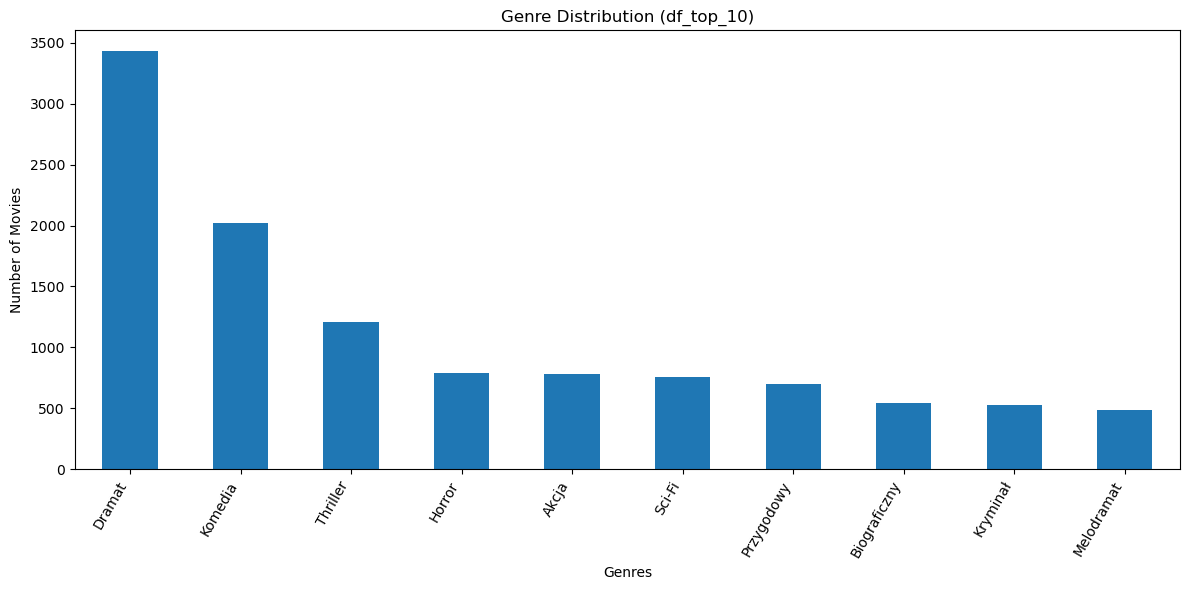

In [73]:
df_top_10 = create_dataset_with_top_genres(df, n=10)

In [66]:
results_top_10_genres = compare_models(df_top_10, models_to_test=models_to_test)


--- Testing LogisticRegression with TF-IDF ---
Extracting features using train_tf_idf...
Training LogisticRegression...
Training LogisticRegression...
Evaluating...

=== Results for LogisticRegression with train_tf_idf ===
Label-wise Accuracy: 0.8800
Sample-wise Accuracy: 0.1872
F1 Score (Macro): 0.1516
F1 Score (Micro): 0.3677

--- Testing LogisticRegression with Bag of Words ---
Extracting features using train_bag_of_words...
Evaluating...

=== Results for LogisticRegression with train_tf_idf ===
Label-wise Accuracy: 0.8800
Sample-wise Accuracy: 0.1872
F1 Score (Macro): 0.1516
F1 Score (Micro): 0.3677

--- Testing LogisticRegression with Bag of Words ---
Extracting features using train_bag_of_words...
Training LogisticRegression...
Training LogisticRegression...
Evaluating...

=== Results for LogisticRegression with train_bag_of_words ===
Label-wise Accuracy: 0.8676
Sample-wise Accuracy: 0.2160
F1 Score (Macro): 0.4104
F1 Score (Micro): 0.4815

--- Testing RandomForestClassifier wit

### Results for TF_IDF and BOW

In [67]:
results__all_data

,label_wise_accuracy,sample_wise_accuracy,f1_macro,f1_micro
LogisticRegression_tfidf,0.971901,0.065126,0.022425,0.170114
LogisticRegression_bow,0.968899,0.103466,0.119597,0.331011
RandomForestClassifier_tfidf,0.971332,0.044643,0.031014,0.128758
RandomForestClassifier_bow,0.971183,0.042542,0.015657,0.126790


In [68]:
results_top_10_genres

,label_wise_accuracy,sample_wise_accuracy,f1_macro,f1_micro
LogisticRegression_tfidf,0.880000,0.187220,0.151552,0.367677
LogisticRegression_bow,0.867604,0.215974,0.410367,0.481481
RandomForestClassifier_tfidf,0.877508,0.182109,0.169731,0.362911
RandomForestClassifier_bow,0.874249,0.173163,0.138751,0.334686


In [74]:
df_train, df_val = train_test_split(df_top_10, test_size=0.2, random_state=42)

genre_to_idx, idx_to_genre = build_label_mappings(df_top_10)
train_dataset = build_dataset(df_train, genre_to_idx)
validation_dataset = build_dataset(df_val, genre_to_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)

In [84]:
num_labels = len(genre_to_idx)
model = HerBERTFrozenMultiLabelClassifier(num_labels=num_labels)

trained_model = train_model(
    model=model,
    train_loader=train_loader,
	val_loader=validation_loader,
	num_epochs=5
)

Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/5 Validation: 100%|██████████| 98/98 [00:35<00:00,  2.78it/s]


Epoch 1, Train Loss: 0.3933, Val Loss: 0.3620
Validation metrics: Label-wise Accuracy: 0.8415, Sample-wise Accuracy: 0.2051, F1 Score: 0.0993, Micro F1 Score: 0.3986


Epoch 2/5 Validation: 100%|██████████| 98/98 [00:34<00:00,  2.83it/s]


Epoch 2, Train Loss: 0.3676, Val Loss: 0.3575
Validation metrics: Label-wise Accuracy: 0.8302, Sample-wise Accuracy: 0.1776, F1 Score: 0.1049, Micro F1 Score: 0.4131


Epoch 3/5 Validation: 100%|██████████| 98/98 [00:36<00:00,  2.71it/s]


Epoch 3, Train Loss: 0.3628, Val Loss: 0.3534
Validation metrics: Label-wise Accuracy: 0.8148, Sample-wise Accuracy: 0.1393, F1 Score: 0.1082, Micro F1 Score: 0.4176


Epoch 4/5 Validation: 100%|██████████| 98/98 [00:36<00:00,  2.72it/s]



Epoch 4, Train Loss: 0.3570, Val Loss: 0.3493
Validation metrics: Label-wise Accuracy: 0.8284, Sample-wise Accuracy: 0.1712, F1 Score: 0.1201, Micro F1 Score: 0.4224


Epoch 5/5 Validation: 100%|██████████| 98/98 [00:35<00:00,  2.75it/s]

Epoch 5, Train Loss: 0.3521, Val Loss: 0.3460
Validation metrics: Label-wise Accuracy: 0.8289, Sample-wise Accuracy: 0.1712, F1 Score: 0.1443, Micro F1 Score: 0.4318


In [87]:
def predict_genres(
    model: torch.nn.Module,
    tokenizer,
    texts: list[str] | str,
    idx_to_genre: dict,
    true_genres: list[list[str]] = None,
    threshold: float = 0.25,
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Predict genres for given text(s) using the trained model.
    
    Args:
        model: Trained PyTorch model
        tokenizer: Tokenizer used for the model
        texts: Single string or list of strings to predict
        idx_to_genre: Dictionary mapping indices to genre names
        true_genres: Optional list of true genres for comparison
        threshold: Probability threshold for classification
        device: Device to run prediction on
    """
    model.eval()
    model.to(device)
    
    if isinstance(texts, str):
        texts = [texts]
        
    # Tokenization
    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    
    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)
    
    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        probabilities = torch.sigmoid(logits)
        
    results = []
    for idx, probs in enumerate(probabilities):
        # Get indices where probability > threshold
        predicted_indices = (probs > threshold).nonzero().flatten().tolist()
        predicted_genres = [idx_to_genre[i] for i in predicted_indices]
        
        # Get probabilities for predicted genres
        genre_probs = {idx_to_genre[i]: probs[i].item() for i in range(len(probs))}
        
        # Sort all probabilities to show top ones
        sorted_probs = dict(sorted(genre_probs.items(), key=lambda item: item[1], reverse=True))
        
        results.append({
            'text': texts[idx],
            'predicted_genres': predicted_genres,
            'all_probabilities': sorted_probs
        })
        
        print(f"\n--- Text: {texts[idx][:100]}... ---")
        if true_genres is not None and idx < len(true_genres):
            print(f"True genres:      {true_genres[idx]}")
        print(f"Predicted genres: {predicted_genres}")
        print("Top 5 probabilities:")
        for genre, prob in list(sorted_probs.items())[:5]:
            print(f"  {genre}: {prob:.4f}")
            
    return results

In [90]:
tokenizer = AutoTokenizer.from_pretrained("allegro/herbert-base-cased")

# Pick some examples from validation set
sample_texts = df_val['description'].head(5).tolist()
sample_true_genres = df_val['genres'].head(5).tolist()

print("=== Sample Predictions ===")
predictions = predict_genres(
    model, 
    tokenizer, 
    sample_texts, 
    idx_to_genre, 
    true_genres=sample_true_genres, 
    threshold=0.3
)

=== Sample Predictions ===

--- Text: Tami i Richard, dwoje szaleńczo zakochanych młodych żeglarzy wyrusza w rejs przez Pacyfik do odległe... ---
True genres:      ['Dramat']
Predicted genres: ['Dramat']
Top 5 probabilities:
  Dramat: 0.3867
  Komedia: 0.2906
  Thriller: 0.2074
  Horror: 0.1189
  Akcja: 0.0954

--- Text: Elaine (Samantha Robinson) to piękna i młoda wiedźma, która chce odnaleźć miłość swojego życia. Prob... ---
True genres:      ['Horror', 'Komedia']
Predicted genres: ['Dramat']
Top 5 probabilities:
  Dramat: 0.4254
  Komedia: 0.2738
  Thriller: 0.2039
  Akcja: 0.0803
  Horror: 0.0784

--- Text: Po brutalnym zabiciu własnej rodziny Christian Longo (James Franco) znajduje się na liście FBI najba... ---
True genres:      ['Dramat']
Predicted genres: ['Dramat']
Top 5 probabilities:
  Dramat: 0.3968
  Thriller: 0.2782
  Komedia: 0.1821
  Horror: 0.1616
  Kryminał: 0.1612

--- Text: Film opowiadający losy najwybitniejszego malarza ikon w średniowiecznej Rusi. Żył w XV wieku,

# Analiza problemów z uczeniem modelu

Twój model (`HerBERTFrozenMultiLabelClassifier`) może mieć problemy z nauką z kilku kluczowych powodów:

1.  **Niezbalansowane dane i funkcja straty (Imbalance & Loss Function)**:
    *   Nawet po ograniczeniu do 10 najpopularniejszych gatunków, zbiór danych prawdopodobnie nadal jest niezbalansowany (np. "Dramat" może mieć 2000 wystąpień, a 10-ty gatunek tylko 500).
    *   Używasz funkcji `train_model`, która korzysta ze standardowej funkcji straty `BCEWithLogitsLoss` **bez wag**.
    *   W klasyfikacji wieloetykietowej (multi-label), gdzie dla każdego przykładu większość etykiet to "0", model bardzo szybko uczy się, że najbezpieczniejszą strategią minimalizacji błędu jest przewidywanie samych zer (brak gatunku).

2.  **Zamrożony Encoder (Frozen Encoder)**:
    *   Używasz `HerBERTFrozenMultiLabelClassifier`, który nie aktualizuje wag HerBERTa.
    *   Model uczy się tylko małej warstwy klasyfikującej na końcu. Jeśli ogólne wektory (embeddings) z HerBERTa nie są wystarczająco separowalne dla specyficznych gatunków filmowych, ta mała warstwa nie będzie w stanie ich poprawnie rozdzielić.
    *   **Rozwiązanie**: Warto spróbować "odmrozić" model (`HerBERTMultiLabelClassifier`) i trenować go z bardzo małym Learning Rate (np. `2e-5`).

3.  **Globalna zmienna `weights`**:
    *   Wcześniejsza funkcja `train_model_with_weighted_loss` polegała na globalnej zmiennej `weights`, która była wyliczona dla całego zbioru danych. Teraz pracujemy na podzbiorze (`df_top_10`), więc wagi muszą być przeliczone dla tego konkretnego podzbioru, aby pasowały wymiarami i wartościami.

### Rozwiązanie

Poniżej znajduje się poprawiona funkcja treningowa, która przyjmuje wagi jako argument, oraz kod obliczający wagi dla aktualnego podzbioru danych.